In [15]:
import numpy as np
import pandas as pd
from collections import Counter
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [16]:
# --- Load Iris dataset from CSV ---
df = pd.read_csv("Iris.csv")


In [17]:

# Split features and labels
X = df.drop(columns=["species"]).values
y = df["species"].values


   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

  species  
0  setosa  
1  setosa  
2  setosa  
3  setosa  
4  setosa  


In [18]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [19]:
# --- k-NN implementation from scratch ---
class KNN:
    def __init__(self, k=3):
        self.k = k

    def fit(self, X, y):
        self.X_train = X
        self.y_train = y

    def predict(self, X):
        return np.array([self._predict(x) for x in X])

    def _predict(self, x):
        # compute Euclidean distances
        distances = [np.sqrt(np.sum((x - x_train) ** 2)) for x_train in self.X_train]

        # get indices of k nearest neighbors
        k_idx = np.argsort(distances)[:self.k]
        k_neighbor_labels = [self.y_train[i] for i in k_idx]

        # majority vote
        most_common = Counter(k_neighbor_labels).most_common(1)
        return most_common[0][0]

In [20]:
for k in k_values:
    model = KNN(k=k)
    model.fit(X_train, y_train)   # now X_train is defined ✅
    preds = model.predict(X_test)
    acc = np.mean(preds == y_test)
    accuracies.append(acc)
    print(f"k = {k}, Accuracy = {acc:.3f}")


k = 1, Accuracy = 1.000
k = 2, Accuracy = 1.000
k = 3, Accuracy = 1.000
k = 4, Accuracy = 1.000
k = 5, Accuracy = 1.000
k = 6, Accuracy = 1.000
k = 7, Accuracy = 1.000
k = 8, Accuracy = 1.000
k = 9, Accuracy = 1.000
k = 10, Accuracy = 1.000
k = 11, Accuracy = 1.000
k = 12, Accuracy = 1.000
k = 13, Accuracy = 1.000
k = 14, Accuracy = 1.000
k = 15, Accuracy = 1.000
k = 16, Accuracy = 1.000
k = 17, Accuracy = 1.000
k = 18, Accuracy = 1.000
k = 19, Accuracy = 1.000
k = 20, Accuracy = 1.000


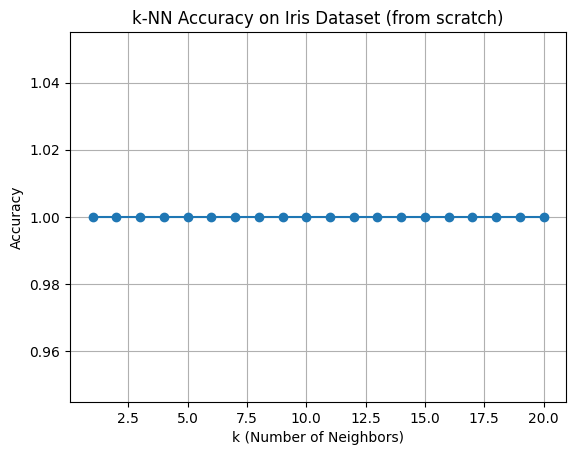

In [21]:
# --- Plot accuracy vs k ---
plt.plot(k_values, accuracies, marker="o")
plt.xlabel("k (Number of Neighbors)")
plt.ylabel("Accuracy")
plt.title("k-NN Accuracy on Iris Dataset (from scratch)")
plt.grid(True)
plt.show()